In [1]:
import polars_bio as pb
import pandas as pd
from polars_bio.io import read_fastq
import polars as pl
import time
import matplotlib.pyplot as plt

/home/natkk/polars-bio/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:polars_bio:Creating BioSessionContext
INFO:polars_bio.context:kmer_count UDAF registered


In [3]:
def display_graph(df):
    plt.figure(figsize=(12, 6))
    for base in ["A", "C", "G", "T", "N"]:
        plt.plot(df["position"], df[base], label=base)

    plt.xlabel("Position")
    plt.ylabel("Base Count")
    plt.title("Base Sequence Content Per Position")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
file_name = "example"
read_fastq(file_name + ".fastq")

INFO:polars_bio:Table: example registered for path: example.fastq


In [5]:
start = time.time()

In [6]:
pb.ctx.set_option("datafusion.execution.target_partitions", "2")
df = pb.sql(f"SELECT base_content_multithreaded(sequence) AS result FROM {file_name}").collect()

1rows [00:00, 36.81rows/s]


In [7]:
end = time.time()
print(f"EXECUTION TIME: {end - start}")

EXECUTION TIME: 2.6001076698303223


In [8]:
exploded = df.explode("result")

In [9]:
flat = exploded.select([
        pl.col("result").struct.field("position"),
        pl.col("result").struct.field("A"),
        pl.col("result").struct.field("C"),
        pl.col("result").struct.field("G"),
        pl.col("result").struct.field("T"),
        pl.col("result").struct.field("N"),
    ])
print(flat)

shape: (101, 6)
┌──────────┬─────┬─────┬─────┬─────┬─────┐
│ position ┆ A   ┆ C   ┆ G   ┆ T   ┆ N   │
│ ---      ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│ i64      ┆ i64 ┆ i64 ┆ i64 ┆ i64 ┆ i64 │
╞══════════╪═════╪═════╪═════╪═════╪═════╡
│ 1        ┆ 42  ┆ 51  ┆ 48  ┆ 46  ┆ 13  │
│ 2        ┆ 48  ┆ 51  ┆ 40  ┆ 61  ┆ 0   │
│ 3        ┆ 57  ┆ 51  ┆ 43  ┆ 49  ┆ 0   │
│ 4        ┆ 45  ┆ 48  ┆ 52  ┆ 55  ┆ 0   │
│ 5        ┆ 57  ┆ 45  ┆ 46  ┆ 52  ┆ 0   │
│ …        ┆ …   ┆ …   ┆ …   ┆ …   ┆ …   │
│ 97       ┆ 54  ┆ 42  ┆ 52  ┆ 45  ┆ 7   │
│ 98       ┆ 46  ┆ 44  ┆ 52  ┆ 47  ┆ 11  │
│ 99       ┆ 46  ┆ 55  ┆ 52  ┆ 47  ┆ 0   │
│ 100      ┆ 54  ┆ 49  ┆ 46  ┆ 51  ┆ 0   │
│ 101      ┆ 64  ┆ 34  ┆ 42  ┆ 60  ┆ 0   │
└──────────┴─────┴─────┴─────┴─────┴─────┘


In [10]:
nested_list = df["result"][0]
df_converted = pd.DataFrame(nested_list, columns=["position", "A", "C", "G", "T", "N"])   

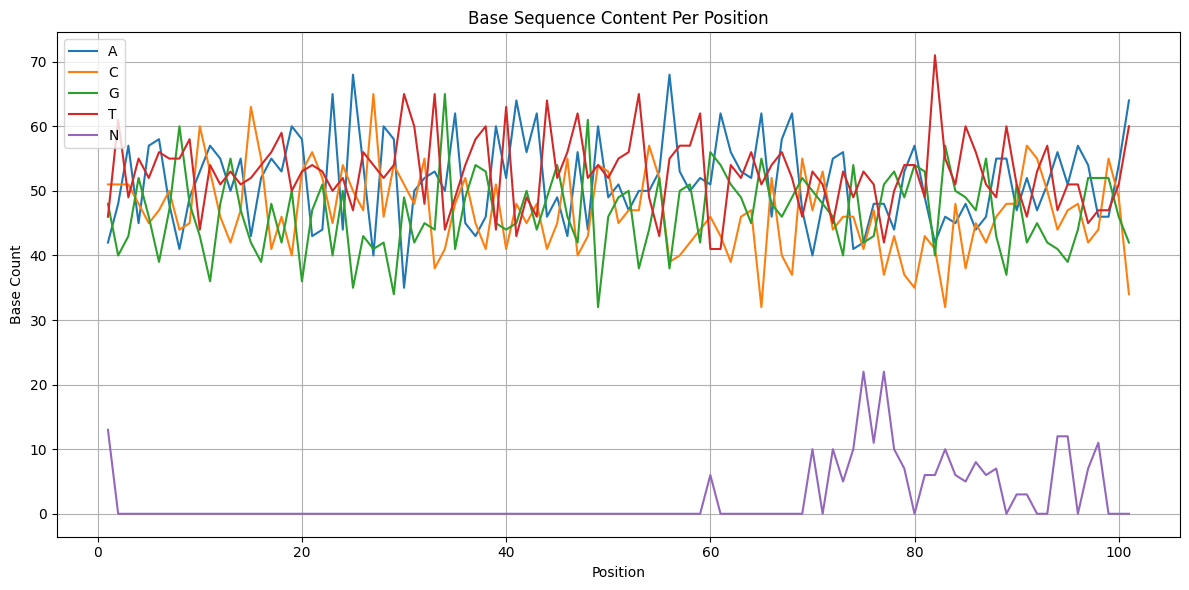

In [11]:
display_graph(df_converted)

In [13]:
!pytest ../tests/test_base_sequence_content.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-8.4.0, pluggy-1.6.0 -- /home/natkk/polars-bio/.venv/bin/python3
cachedir: .pytest_cache
rootdir: /home/natkk/polars-bio
configfile: pyproject.toml
collected 4 items                                                              

../tests/test_base_sequence_content.py::test_base_content_matches_expected PASSED [ 25%]
../tests/test_base_sequence_content.py::test_empty_fastq PASSED          [ 50%]
../tests/test_base_sequence_content.py::test_all_N_fastq PASSED          [ 75%]
../tests/test_base_sequence_content.py::test_invalid_characters PASSED   [100%]

=============================== warnings summary ===============================
tests/test_base_sequence_content.py::test_base_content_matches_expected
  /home/natkk/polars-bio/tests/test_base_sequence_content.py:21: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_

INFO:polars_bio:Table: err194147 registered for path: ../ERR194147.fastq
1rows [00:39, 39.56s/rows]


[Multithreaded] Execution time: 39.5697s


1rows [00:45, 45.85s/rows]

[Single-threaded] Execution time: 45.8607s


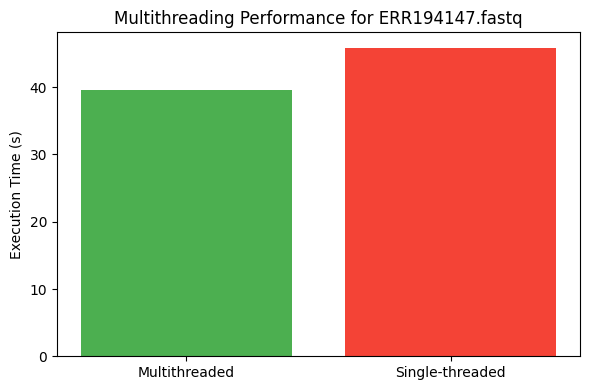

In [16]:
import time
import matplotlib.pyplot as plt
import polars_bio as pb
from polars_bio import read_fastq

file_path = "../ERR194147.fastq"
table_name = "ERR194147"

# file_path = "example.fastq"
# table_name = "example"

read_fastq(file_path)

pb.ctx.set_option("datafusion.execution.target_partitions", "2")
start_multi = time.time()
df_multi = pb.sql(f"SELECT base_content_multithreaded(sequence) AS result FROM {table_name}").collect()
multi_time = time.time() - start_multi
print(f"[Multithreaded] Execution time: {multi_time:.4f}s")

pb.ctx.set_option("datafusion.execution.target_partitions", "1")
start_single = time.time()
df_single = pb.sql(f"SELECT base_content(sequence) AS result FROM {table_name}").collect()
single_time = time.time() - start_single
print(f"[Single-threaded] Execution time: {single_time:.4f}s")

labels = ["Multithreaded", "Single-threaded"]
times = [multi_time, single_time]

plt.figure(figsize=(6, 4))
plt.bar(labels, times, color=["#4caf50", "#f44336"])
plt.ylabel("Execution Time (s)")
plt.title("Multithreading Performance for ERR194147.fastq")
plt.tight_layout()
plt.show()

In [15]:
%matplotlib inline
!python ../tests/test_base_seq_content_multithreading.py

INFO:polars_bio:Creating BioSessionContext
INFO:polars_bio.context:kmer_count UDAF registered
INFO:polars_bio:Table: example registered for path: ../tbd-project/example.fastq
1rows [00:00, 1033.84rows/s]
[Multithreaded] Execution time: 0.0404s
1rows [00:00, 134.28rows/s]
[Single-threaded] Execution time: 0.0134s
Saved plot to multithreading_benchmark.png
Traceback (most recent call last):
  File "/home/natkk/polars-bio/tbd-project/../tests/test_base_seq_content_multithreading.py", line 39, in <module>
    assert multi_time <= single_time * (1 + tolerance), (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Multithreaded version slower: 0.0404s vs 0.0134s


INFO:polars_bio:Table: example registered for path: example.fastq
1rows [00:00, 340.28rows/s]


[polars_bio] example.fastq → 0.01 sec


INFO:polars_bio:Table: err194147 registered for path: ../ERR194147.fastq


[fastqc-rs]  example.fastq → 1.63 sec


1rows [00:42, 42.74s/rows]


[polars_bio] ../ERR194147.fastq → 42.75 sec
[fastqc-rs]  ../ERR194147.fastq → 47.63 sec


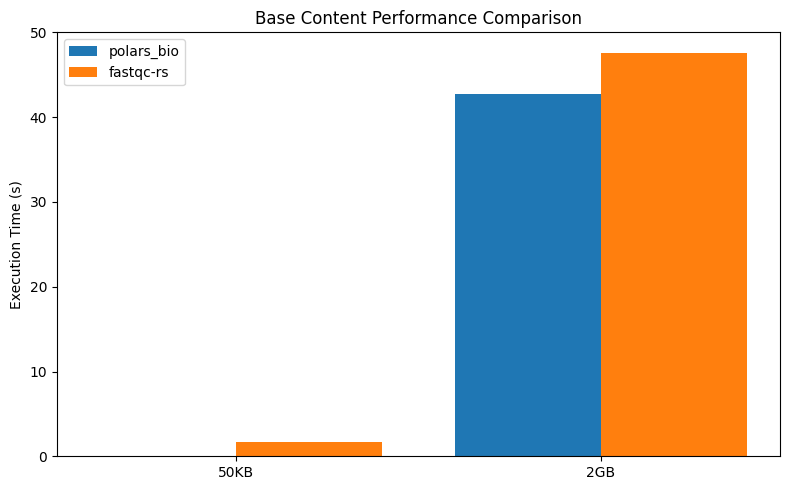

In [20]:
import time
import subprocess
import matplotlib.pyplot as plt
import polars_bio as pb
from polars_bio import read_fastq

datasets = [
    ("example.fastq", "50KB"),
    ("../ERR194147.fastq", "2GB"),
]
results = []

for file_path, size_label in datasets:
    table_name = file_path.split("/")[-1].split(".")[0]

    read_fastq(file_path)  
    start_my = time.time()
    pb.sql(f"SELECT base_content(sequence) AS result FROM {table_name}").collect()
    time_polars = time.time() - start_my
    print(f"[polars_bio] {file_path} → {time_polars:.2f} sec")

    start_fastqc = time.time()
    subprocess.run(
        ["fqc", "-q", file_path, "-k", "5"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        check=True
    )
    time_fastqc = time.time() - start_fastqc
    print(f"[fastqc-rs]  {file_path} → {time_fastqc:.2f} sec")

    results.append((size_label, time_polars, time_fastqc))

labels, polars_times, fastqc_times = zip(*results)
x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, polars_times, width=0.4, label="polars_bio", align='center')
plt.bar([i + 0.4 for i in x], fastqc_times, width=0.4, label="fastqc-rs", align='center')
plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel("Execution Time (s)")
plt.title("Base Content Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()
